<a href="https://colab.research.google.com/github/annaannaR/NOTEBOOKS-FROM-SCHOOL/blob/main/exercises/myExe_MLP2_1_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set()
%matplotlib inline

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Churn case
Let's return to the churn case (=customers stop using a product/service).

Our goal is to predict which Telco customers will churn.

We have a dataset (churn_data.csv) of 10,000 customers. We know these things about the customers:
- What technology they use (e.g. 4G or cable)
- Age
- How long they have been a customer
- How many times they called the helpdesk last year
- The average monthly invoice amount
- A churn indicator: indicates whether the customer churned

Let's first take a look at the data:

In [6]:
df_churn = pd.read_csv("/content/churn_data.csv", delimiter=";", decimal=",")
df_churn.head(10)

,Technology,Age,CustomerSince,SupportCallsLastYear,AverageBill,ChurnIndicator
0,phone,75.0,2010-09-15 16:27:17,6.0,65.0,False
1,phone,13.0,2011-04-07 16:27:17,8.0,35.0,False
2,phone,73.0,2011-03-12 16:27:17,0.0,45.0,False
3,phone,48.0,2013-07-26 16:27:17,1.0,34.0,False
4,phone,70.0,2015-09-09 16:27:17,2.0,56.0,False
5,fiber,58.0,2013-01-15 16:27:17,8.0,11.0,True
6,fiber,52.0,2011-08-19 16:27:17,7.0,12.0,True
7,fiber,14.0,2010-06-29 16:27:17,2.0,86.0,False
8,phone,18.0,2015-12-04 16:27:17,5.0,39.0,False
9,phone,38.0,2013-08-09 16:27:17,5.0,28.0,False


This time we have learned about Classification in our lecture, so we will really focus on the to be predicted value: ChurnIndicator. Will the customer churn yes or no?

#Classification with scikitlearn

Most of the steps are similar to predicting a value (regression), like splitting the dataset into features and target, and using the train_test_split.

Let's start with extracting the target and features.

In [7]:
features = df_churn.drop("ChurnIndicator", axis=1)
target = df_churn.ChurnIndicator

##Preparations
We choose to train a DecisionTree.

In [8]:
from sklearn import tree

In [9]:
# Initialize the model
DT_model = tree.DecisionTreeClassifier()

Theoretically DecisionTrees could use both categorical and numerical values as features. It would just make a 'leaf' based on the categorical value of a feature, and assign a result to it. In SKLearn however it is unfortunately not possible.

This means we first need to do some data transformations (remember: most of the work in data science is feature selection, transformation, creation, tuning etc.).
Luckily there is a trick for using categorical values: we encode the categories to be numerical values.

##Encoding
Depending on your categorical feature you can use 'Label Encoding' or 'OneHotEncoder'.

###Label encoding
Label encoding is used when the categories in your column have some sort of natural order. This approach is very simple and it involves converting each value in a column to a number.

It might for example contain the values 'low/medium/high'. Which you can encode by transforming al 'lows' to value = 1, all 'medium' to value = 2, and all 'highs' to value = 3.

###OneHotEncoding
A lot of categorical features however do not have a natural order. Take for example our feature 'Technology'.
Let's look at which categories it contains.

In [10]:
features['Technology'].value_counts()

,count
Technology,
4G,3401
phone,3021
fiber,2075
landline,1503


We see we have 4 categories: '4G', 'phone', 'fiber' and 'landline'. These are just different kinds of technologies, nothing indicates one of the categories is 'better' compared to the others.
In this case assigning numbers from 1 to 4 to these categories would teach the model the wrong thing, thus we need to find a different solution.

Introducing: one-hot encoding. In this strategy, each category value is converted into a new column and assigned a 1 or 0 (notation for true/false) value to the column.

By doing so we eliminate the hierarchy/order issues. A downside however is we are adding columns, and thus complexity, to the dataset/model. If your categorical feature contains a lot of different categories you might not want to use this tactic, and just skip the feature, or use a different algorithm.

In [11]:
# import the functionality from sklearn
from sklearn.preprocessing import OneHotEncoder

In [12]:
# Initialize the encoder and apply it to our dataset
ohe = OneHotEncoder()
transformed_feature = ohe.fit_transform(features[['Technology']])

The result is a column for every category found in Technology. With each column containing a '0' or a '1' depending whether or not it is the corresponding category for that row.

In [13]:
print("Number of rows and columns: ",transformed_feature.shape)
print(transformed_feature.toarray())

Number of rows and columns:  (10000, 4)
[[0. 0. 0. 1.]
 [0. 0. 0. 1.]
 [0. 0. 0. 1.]
 ...
 [0. 0. 1. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]


We can check the categories in the OneHotEncoder() using '.categories_'

In [14]:
ohe.categories_

[array(['4G', 'fiber', 'landline', 'phone'], dtype=object)]

Let's merge our new columns with our dataset. And because it is no longer needed, we remove the original Technology-column.

In [15]:
# Attach the new columns to the feature-dataset, using the categories-names from the OneHotEncoder()
features[ohe.categories_[0]] = transformed_feature.toarray()

# Drop original Technology column
features.drop("Technology", axis=1, inplace=True)

In [16]:
# Check the resulting features-set
features.head()

,Age,CustomerSince,SupportCallsLastYear,AverageBill,4G,fiber,landline,phone
0,75.0,2010-09-15 16:27:17,6.0,65.0,0.0,0.0,0.0,1.0
1,13.0,2011-04-07 16:27:17,8.0,35.0,0.0,0.0,0.0,1.0
2,73.0,2011-03-12 16:27:17,0.0,45.0,0.0,0.0,0.0,1.0
3,48.0,2013-07-26 16:27:17,1.0,34.0,0.0,0.0,0.0,1.0
4,70.0,2015-09-09 16:27:17,2.0,56.0,0.0,0.0,0.0,1.0


The final preprocessing-step we are going to take is drop the 'CustomerSince' column. This column contains data in the form of a datetime, which we will discuss in our last class. For now we cannot easily use it as a numerical value (which the DT needs), so we choose to drop it.

In [17]:
features.drop("CustomerSince", axis=1, inplace=True)

## Modeling

Ok, done with the preprocessing.

Remember in real life projects: you might have to do some more preprocessing. Depending on the algorithm you might have to scale (e.g. log-scaling with linear modeling), or maybe you have to drop features because they only contain low-quality data.

We go on to the train_test_split and fitting of our model.

In [18]:
# import sklearn train_test_split functionality
from sklearn.model_selection import train_test_split

In [19]:
features_train, features_test, target_train, target_test = train_test_split(features,
                                                                            target,
                                                                            test_size=0.2,
                                                                            random_state=1)

Let's double check whether the split went well.

In [20]:
features_train.shape, features_test.shape, target_train.shape, target_test.shape

((8000, 7), (2000, 7), (8000,), (2000,))

We see that of the 10000 entries in the dataset, 2000 have ended up in the test set. That is indeed exactly 20%. Furthermore, we see that both features datasets contain 7 columns, and that for both target datasets the result appears to be a Series object (1 column).

In [21]:
features_train.head()

,Age,SupportCallsLastYear,AverageBill,4G,fiber,landline,phone
2694,42.0,5.0,93.0,0.0,0.0,0.0,1.0
5140,75.0,0.0,21.0,0.0,0.0,1.0,0.0
2568,17.0,0.0,108.0,0.0,0.0,0.0,1.0
3671,13.0,6.0,81.0,1.0,0.0,0.0,0.0
7427,15.0,4.0,19.0,0.0,0.0,1.0,0.0


In [22]:
target_train.head()

,ChurnIndicator
2694,False
5140,False
2568,False
3671,False
7427,False


We can finally fit our initialized DecitionTree-model (DT_model) to our train dataset.

In [23]:
DT_model.fit(features_train, target_train)

DecisionTreeClassifier()

It has now created the DT based on the training-set.

If we want to see which patterns/splits it learned, we can plot the tree using .plot_tree():

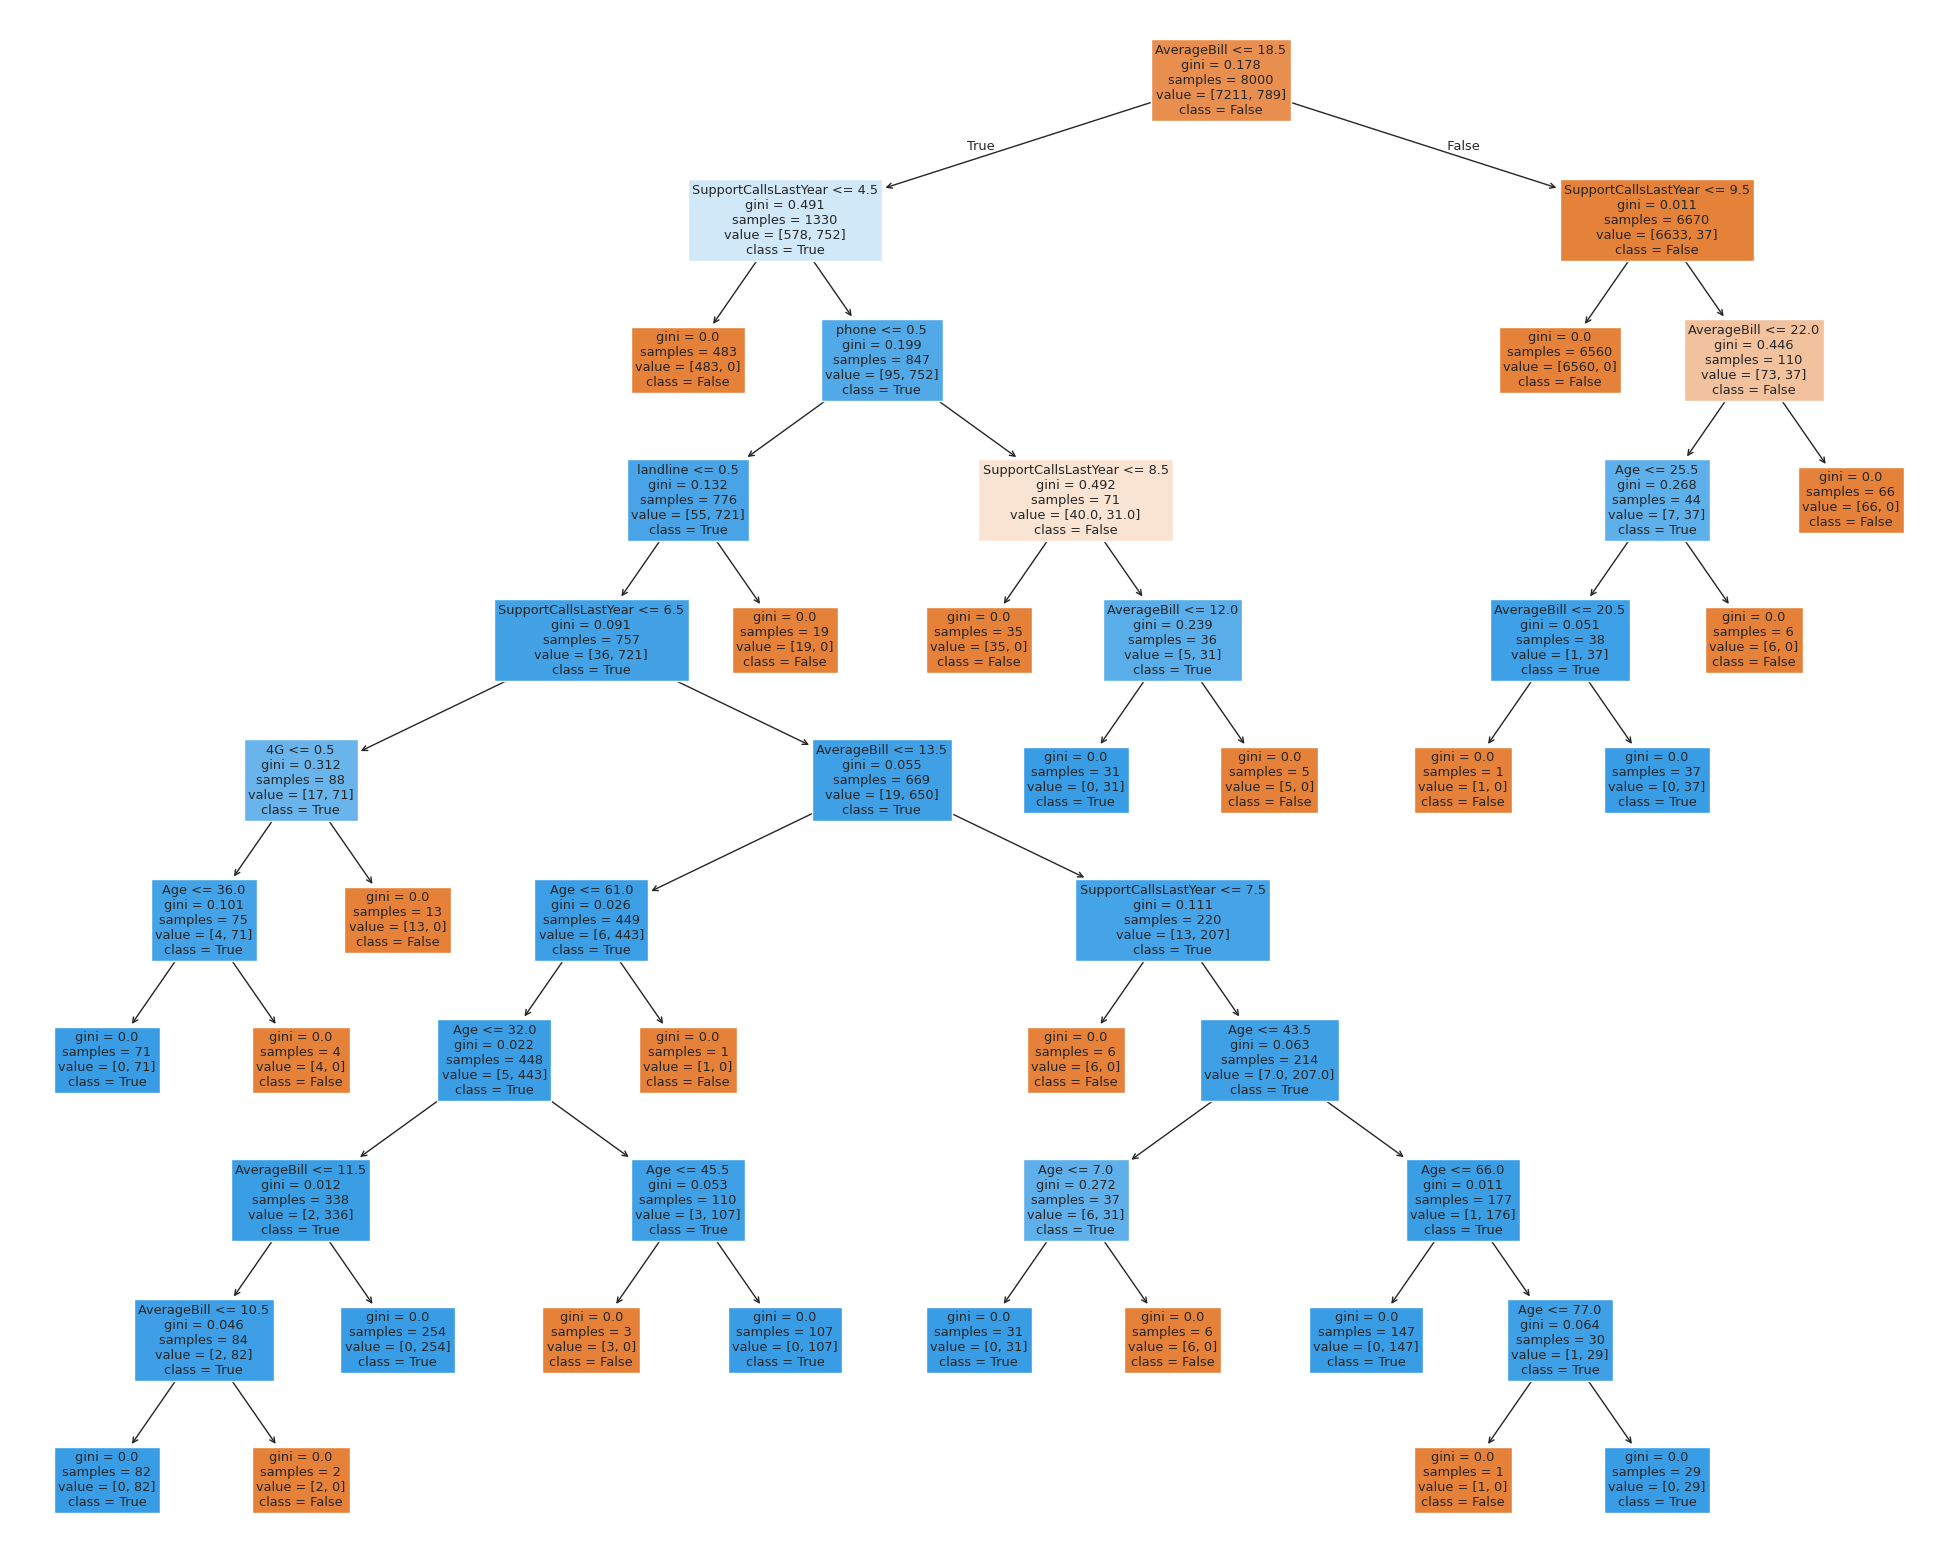

In [24]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(DT_model,
                   feature_names=features.columns,
                   class_names=['False',  'True'],
                   filled=True)

##Using the model for predictions on new data

We can use the trained Decision Tree for predictions on new data from the test set.

In [25]:
target_pred = DT_model.predict(features_test)
# Check result
target_pred

array([False, False, False, ...,  True,  True, False])

We are going to check the performance of our model, by comparing these predictions to the known values in target_test.

In [26]:
# Import performance-functions
from sklearn.metrics import accuracy_score, confusion_matrix

In [27]:
# Get accuracy-score
print("Accuracy: ",accuracy_score(target_test, target_pred))

Accuracy:  0.998


The accuracy score above shows for what percentage of the test set the model got it right.

How do we actually interpret this accuracy?

1 is the highest possible accuracy, which means that the model correctly predicted 100% of the test set. While 0 means that the model did not make any good predictions.

We are now at an accuracy of 99.8%, which is really high. But is it also good?

It depends on the number of classes and the class distribution. Suppose 1 class makes up 80% of the data, and you always choose that class? Then you are right in 80% of the cases with a simple heuristic.

It is therefore best to compare your model with a very simple baseline (which we have seen before).

In [28]:
from sklearn.dummy import DummyClassifier
# DummyClassifier always predicts majority class (= most frequent class)
dummy = DummyClassifier(strategy='most_frequent')

dummy.fit(features_train, target_train)
dy_pred = dummy.predict(features_test)
print("Dummy accuracy: ",accuracy_score(target_test, dy_pred))

Dummy accuracy:  0.8945


We see the dummy-classifier also has a quite high accuracy, but our model (luckily) outperforms it.

##Confusion matrix

Only looking at the accuracy can be misleading. That is why we often also look at the confusion matrix. Using that we can see what kind of errors the model makes.

In [29]:
cm = confusion_matrix(target_test, target_pred, labels=DT_model.classes_)
cm

array([[1785,    4],
       [   0,  211]])

The confusion matrix indicates how many misclassifications the model has made.

The rows indicate what the real category was, and the columns indicate the predicted category.

We can make this a little more readable by using the ConfusionMatrixDisplay functionality:

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

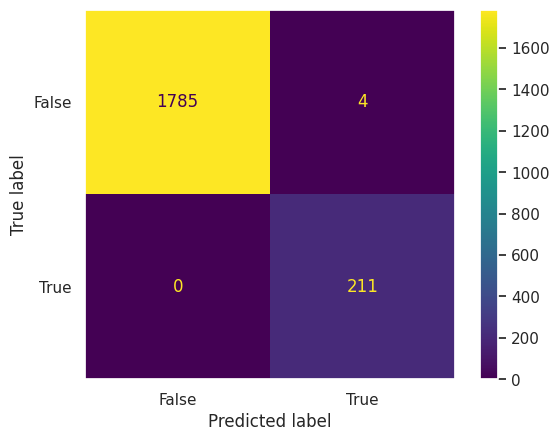

In [31]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=DT_model.classes_)
disp.plot()
plt.grid(False)
plt.show()

**Question**

Do you see how the values in the confusion matrix relate to the accuracy score? How could you calculate the accuracy score from this matrix?

# Assignment 2.1

**Practice with making your own classification model**

Now you get to practice with training and evaluating a classification model.
Below we first generate a dataset to use in this question.

In [32]:
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=1000, shuffle=True, noise=0.4, random_state=1)
df_moons = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_moons["target"] = y

Explore the dataset, choose which classification-model would be most suitable to use, and train and evaluate that model on the dataset.

(You could also choose to train and evaluate several classification-models, and select which performs best).

In [33]:
!pip install scikit-learn

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

X, y = make_moons(n_samples=1000, shuffle=True, noise=0.4, random_state=1)
df_moons = pd.DataFrame(X, columns=["Feature1", "Feature2"])
df_moons["target"] = y

In [36]:
df_moons.describe()

,Feature1,Feature2,target
count,1000.000000,1000.000000,1000.00000
mean,0.507216,0.252335,0.50000
std,0.961122,0.623465,0.50025
min,-2.217050,-1.757733,0.00000
25%,-0.175532,-0.183661,0.00000
50%,0.528942,0.255103,0.50000
75%,1.214885,0.696439,1.00000
max,2.850565,2.491881,1.00000


<Axes: xlabel='target', ylabel='Feature1'>

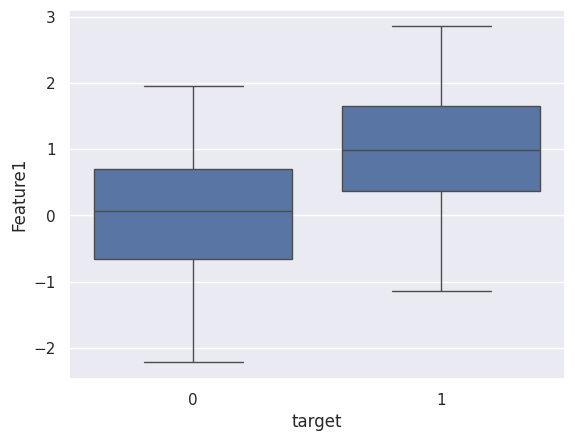

In [37]:
sns.boxplot(x="target", y="Feature1", data=df_moons)

<Axes: xlabel='target', ylabel='Feature2'>

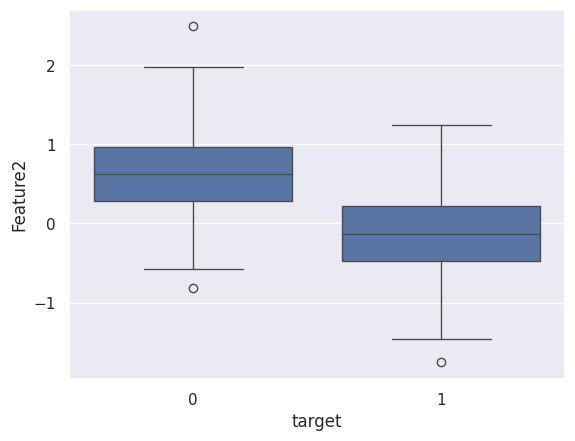

In [38]:
sns.boxplot(x="target", y="Feature2", data=df_moons)

<Axes: xlabel='Feature1', ylabel='Feature2'>

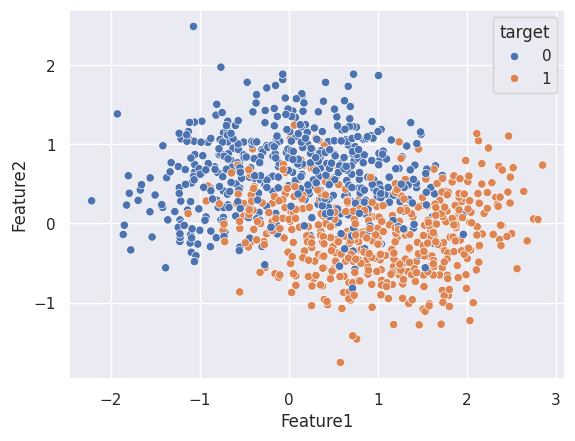

In [39]:
sns.scatterplot(x="Feature1", y="Feature2", hue="target", data=df_moons)

<Axes: xlabel='Feature1', ylabel='Count'>

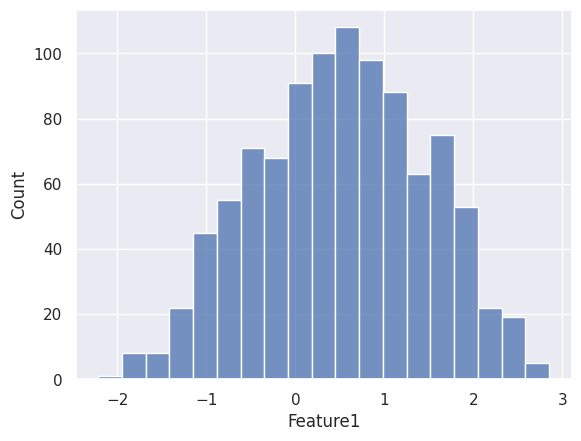

In [40]:
sns.histplot(x="Feature1", data=df_moons)

<Axes: xlabel='Feature2', ylabel='Count'>

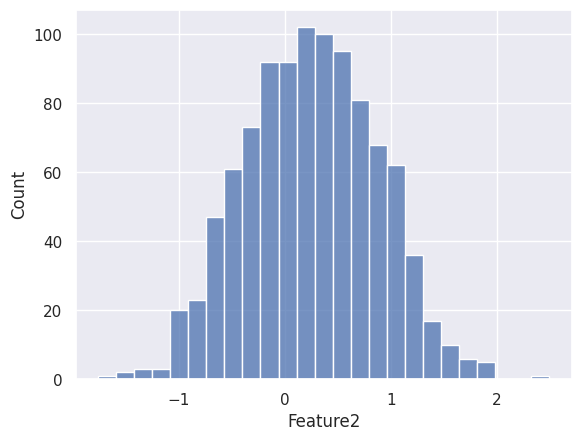

In [41]:
sns.histplot(x="Feature2", data=df_moons)

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2, stratify=y)

In [43]:
tree_clf = DecisionTreeClassifier(max_depth=5, random_state=2)         # drzewo decyzyjne # stworzony model

In [44]:
tree_clf.fit(X_train, y_train)
y_pred = tree_clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.845

### wytrenować reszte modeli - napisać wnioski który model jest najlepszy, standard scalen dla modelu svc